In [780]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


In [781]:
data = yf.download("AAPL", period="730d", interval="4h")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395
2022-06-02 17:30:00+00:00,151.229996,151.270004,150.029999,150.179993,19926032
2022-06-03 13:30:00+00:00,145.350006,147.970001,144.460007,147.000000,55128553


In [782]:
def add_moving_averages(df: pd.DataFrame, spans = [5, 10, 20]):
  for span in spans:
    data[f"MA{span}"] = df["Close"].rolling(window=span*2).mean()
  
  return df

data = add_moving_averages(data)

data.head()

Price,Close,High,Low,Open,Volume,MA5,MA10,MA20
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Datetime,,,,,,,,
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,NaN,NaN,NaN
2022-06-02 17:30:00+00:00,151.229996,151.270004,150.029999,150.179993,19926032,NaN,NaN,NaN
2022-06-03 13:30:00+00:00,145.350006,147.970001,144.460007,147.000000,55128553,NaN,NaN,NaN


In [783]:
def add_rsi(df: pd.DataFrame):
  delta = df["Close"].diff()

  up = delta.clip(lower=0)
  down = -1 * delta.clip(upper=0)

  avg_gain = up.rolling(window=14*2).mean()
  avg_loss = down.rolling(window=14*2).mean()

  rs = avg_gain / avg_loss

  df["RSI14"] = 100 - (100 / (rs + 1))

  return df

data = add_rsi(data)

data.head()

Price,Close,High,Low,Open,Volume,MA5,MA10,MA20,RSI14
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Datetime,,,,,,,,,
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,NaN,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,NaN,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,NaN,NaN,NaN,NaN
2022-06-02 17:30:00+00:00,151.229996,151.270004,150.029999,150.179993,19926032,NaN,NaN,NaN,NaN
2022-06-03 13:30:00+00:00,145.350006,147.970001,144.460007,147.000000,55128553,NaN,NaN,NaN,NaN


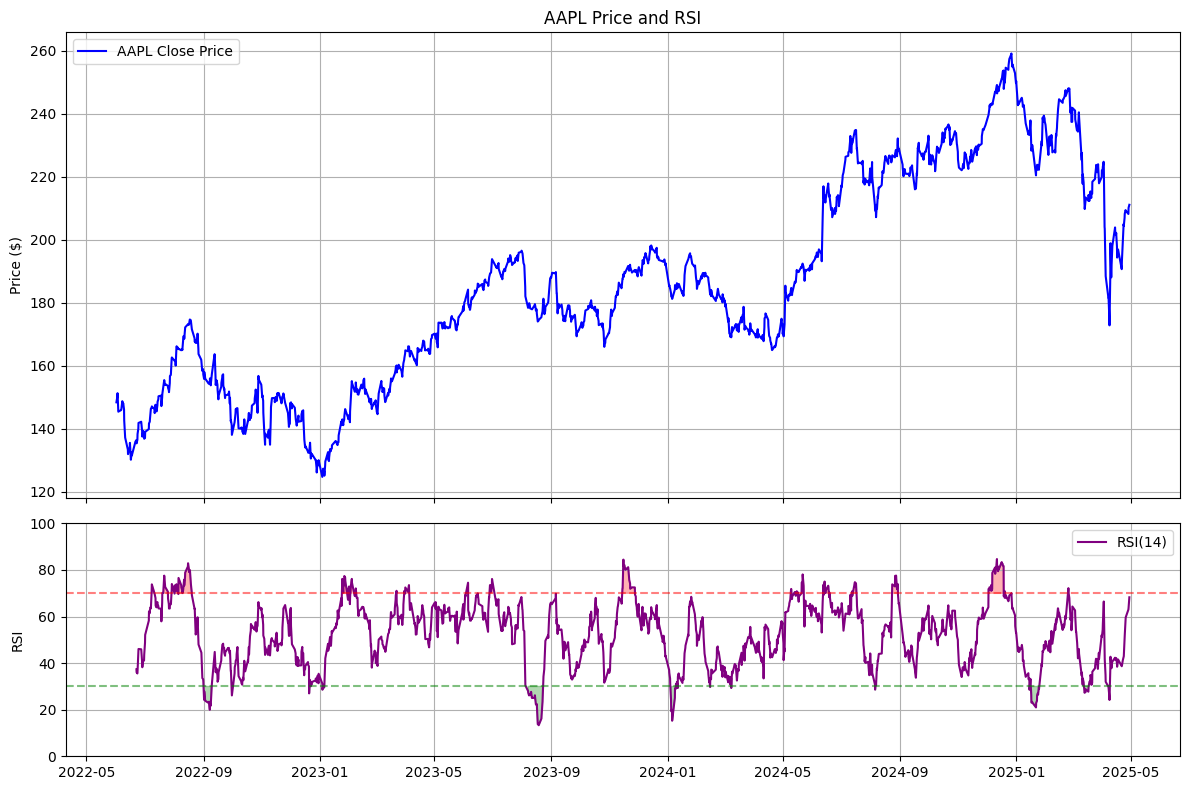

In [784]:
# Create a figure with two subplots (price and RSI)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Plot the closing price on the top subplot
ax1.plot(data.index, data['Close'], label='AAPL Close Price', color='blue')
ax1.set_title('AAPL Price and RSI')
ax1.set_ylabel('Price ($)')
ax1.grid(True)
ax1.legend()

# Plot the RSI on the bottom subplot
ax2.plot(data.index, data['RSI14'], label='RSI(14)', color='purple')
ax2.axhline(y=70, color='r', linestyle='--', alpha=0.5)  # Overbought line
ax2.axhline(y=30, color='g', linestyle='--', alpha=0.5)  # Oversold line
ax2.fill_between(data.index, data['RSI14'], 70, where=(data['RSI14'] >= 70), color='red', alpha=0.3)  # Overbought areas
ax2.fill_between(data.index, data['RSI14'], 30, where=(data['RSI14'] <= 30), color='green', alpha=0.3)  # Oversold areas
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [785]:
def add_standard_deviations(df: pd.DataFrame, spans=[5, 10, 20]):
  for span in spans:
    df[f"SD{span}"] = df["Close"].rolling(window=span*2).std()

  return df

data = add_standard_deviations(data)

data.head()

Price,Close,High,Low,Open,Volume,MA5,MA10,MA20,RSI14,SD5,SD10,SD20
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,
Datetime,,,,,,,,,,,,
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 17:30:00+00:00,151.229996,151.270004,150.029999,150.179993,19926032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-03 13:30:00+00:00,145.350006,147.970001,144.460007,147.000000,55128553,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [786]:
def add_rate_of_change(df: pd.DataFrame, spans=[5, 10, 20]):
  for span in spans:
    df[f"ROC{span}"] = df["Close"].pct_change(periods=span*2)

  return df

data = add_rate_of_change(data)

data.head()

Price,Close,High,Low,Open,Volume,MA5,MA10,MA20,RSI14,SD5,SD10,SD20,ROC5,ROC10,ROC20
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 17:30:00+00:00,151.229996,151.270004,150.029999,150.179993,19926032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-03 13:30:00+00:00,145.350006,147.970001,144.460007,147.000000,55128553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [787]:
def add_avg_true_range(df: pd.DataFrame):
  df["HighLow"] = df["High"] - df["Low"]
  df["HighClose"] = (df["High"] - df["Close"].shift()).abs()
  df["LowClose"] = (df["Low"] - df["Close"].shift()).abs()

  df["TR"] = df[["HighLow", "HighClose", "LowClose"]].max(axis=1)

  df["ATR14"] = df["TR"].rolling(window=14*2).mean()

  df.drop(columns=["HighLow", "HighClose", "LowClose", "TR"], inplace=True)

  return df

data = add_avg_true_range(data)

data.head()

Price,Close,High,Low,Open,Volume,MA5,MA10,MA20,RSI14,SD5,SD10,SD20,ROC5,ROC10,ROC20,ATR14
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 17:30:00+00:00,151.229996,151.270004,150.029999,150.179993,19926032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-03 13:30:00+00:00,145.350006,147.970001,144.460007,147.000000,55128553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [788]:
def add_bollinger_bands(df: pd.DataFrame, window=20, no_std=2):
  rolling_mean = df["Close"].rolling(window=window*2).mean()
  rolling_std = df["Close"].rolling(window=window*2).std()

  df["BollMid"] = rolling_mean
  df["BollUpper"] = rolling_mean + (no_std * rolling_std)
  df["BollLower"] = rolling_mean - (no_std * rolling_std)

  df["BollBandwidth"] = df["BollUpper"] - df["BollLower"]

  return df

data = add_bollinger_bands(data)

data.head()

Price,Close,High,Low,Open,Volume,MA5,MA10,MA20,RSI14,SD5,SD10,SD20,ROC5,ROC10,ROC20,ATR14,BollMid,BollUpper,BollLower,BollBandwidth
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,,
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 17:30:00+00:00,151.229996,151.270004,150.029999,150.179993,19926032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-03 13:30:00+00:00,145.350006,147.970001,144.460007,147.000000,55128553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


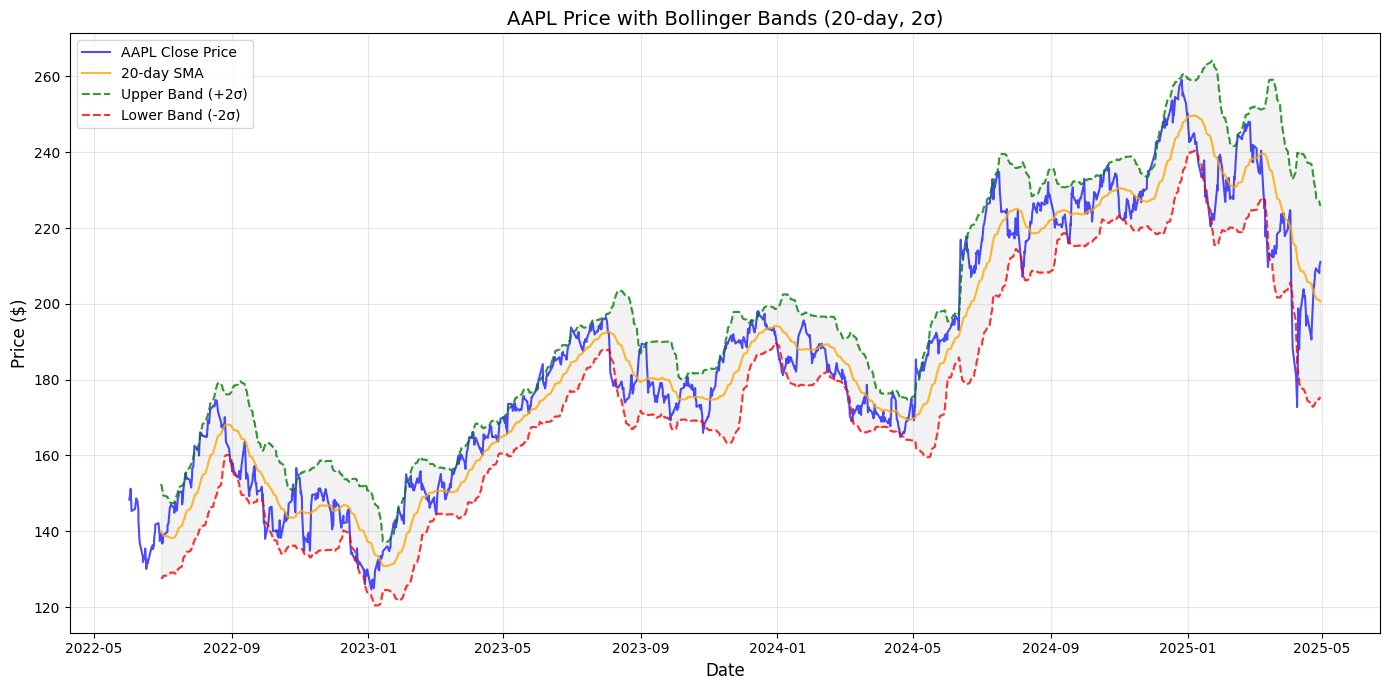

In [789]:
# Create a figure
plt.figure(figsize=(14, 7))

# Plot the closing price
plt.plot(data.index, data['Close'], label='AAPL Close Price', color='blue', alpha=0.7)

# Plot Bollinger Bands
plt.plot(data.index, data['BollMid'], label='20-day SMA', color='orange', alpha=0.8)
plt.plot(data.index, data['BollUpper'], label='Upper Band (+2σ)', color='green', linestyle='--', alpha=0.8)
plt.plot(data.index, data['BollLower'], label='Lower Band (-2σ)', color='red', linestyle='--', alpha=0.8)

# Fill the area between upper and lower bands
plt.fill_between(data.index, data['BollUpper'], data['BollLower'], color='gray', alpha=0.1)

# Add labels and title
plt.title('AAPL Price with Bollinger Bands (20-day, 2σ)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best')

# Show the plot
plt.tight_layout()
plt.show()

In [790]:
def add_ema(df: pd.DataFrame, spans=[5, 12, 26, 50]):
  for span in spans:
    df[f"EMA{span}"] = df["Close"].ewm(span=span*2).mean()

  return df

data = add_ema(data)

In [791]:
def add_macd(df: pd.DataFrame, short_window=12, long_window=26, signal_window=9):
  short_ema = df["Close"].ewm(span=short_window*2, adjust=False).mean()
  long_ema = df["Close"].ewm(span=long_window*2, adjust=False).mean()

  df["MACD"] = short_ema - long_ema
  df["MACD_Signal"] = df["MACD"].ewm(span=signal_window*2, adjust=False).mean()
  df["MACD_Histo"] = df["MACD"] - df["MACD_Signal"]

  return df

data = add_macd(data)

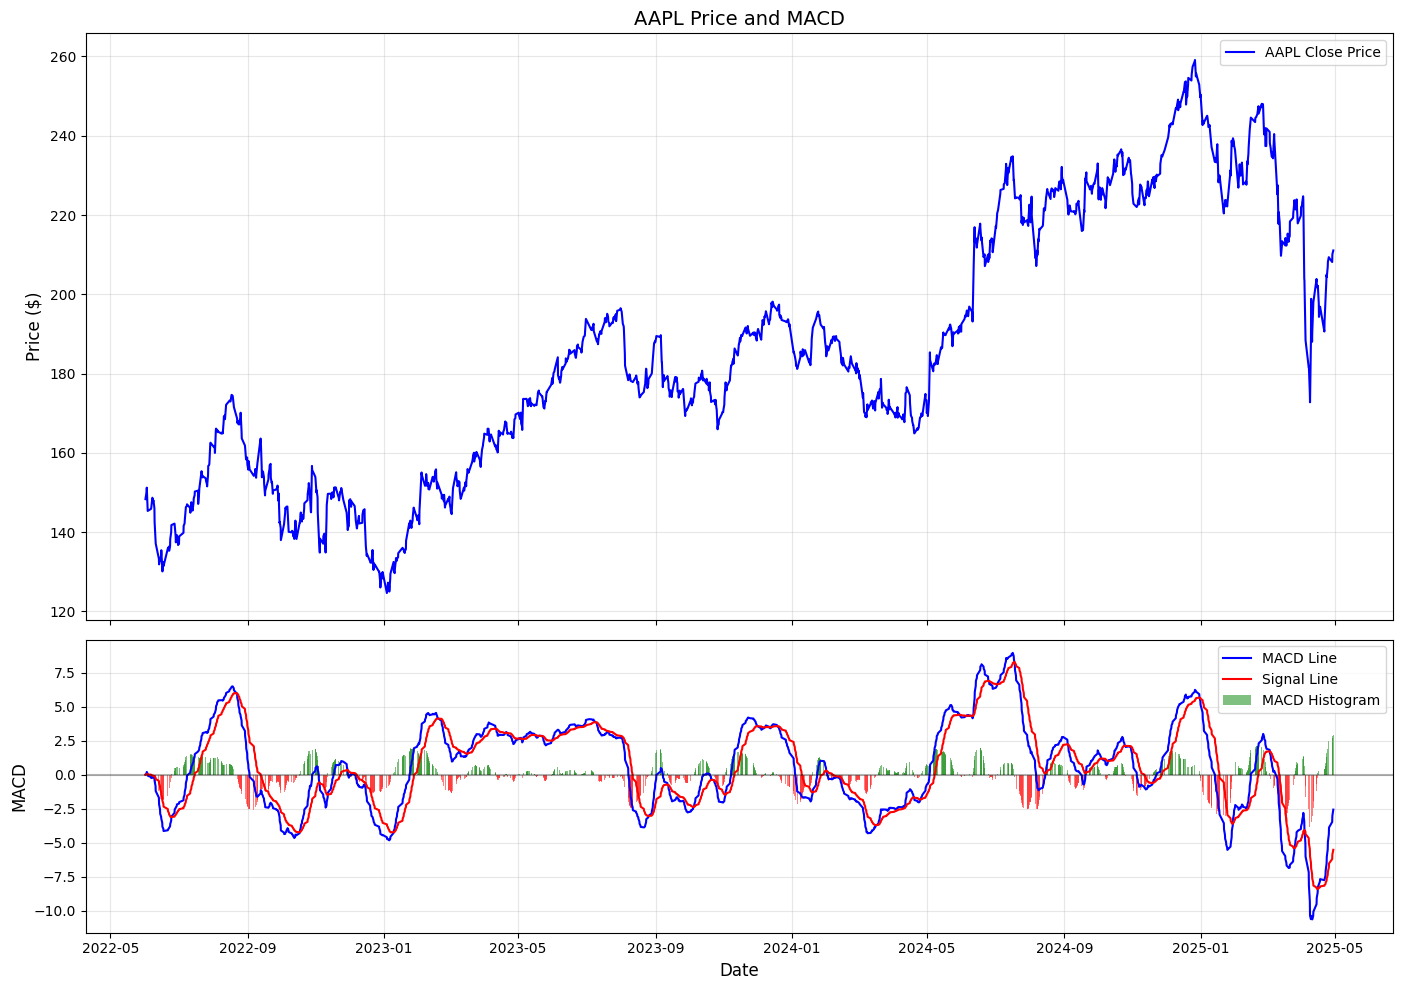

In [792]:
# Create a figure with two subplots (price and MACD)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Plot the closing price on the top subplot
ax1.plot(data.index, data['Close'], label='AAPL Close Price', color='blue')
ax1.set_title('AAPL Price and MACD', fontsize=14)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# Plot the MACD on the bottom subplot
ax2.plot(data.index, data['MACD'], label='MACD Line', color='blue')
ax2.plot(data.index, data['MACD_Signal'], label='Signal Line', color='red')
ax2.bar(data.index, data['MACD_Histo'], label='MACD Histogram', color='green', alpha=0.5, width=0.7)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.set_ylabel('MACD', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')

# Add colors to histogram based on values (green for positive, red for negative)
for i, val in enumerate(data['MACD_Histo']):
    if i < len(data.index):  # Ensure we don't go out of bounds
        if val >= 0:
            ax2.patches[i].set_facecolor('green')
        else:
            ax2.patches[i].set_facecolor('red')

plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()

In [793]:
def add_donchian_channels(df: pd.DataFrame, window=20):
    df["DC_Lower"] = df[("Low", "AAPL")].rolling(window=window*2).min()
    df["DC_Upper"] = df[("High", "AAPL")].rolling(window=window*2).max()
    df["DC_Mid"] = (df[("High", "AAPL")] + df[("Low", "AAPL")]) / 2
    df["DC_Width"] = df["DC_Upper"] - df["DC_Lower"]
    
    df["DC_Breakout_Strength"] = (df[("Close", "AAPL")] - df["DC_Mid"]) / df["DC_Width"]
    
    return df

data = add_donchian_channels(data)

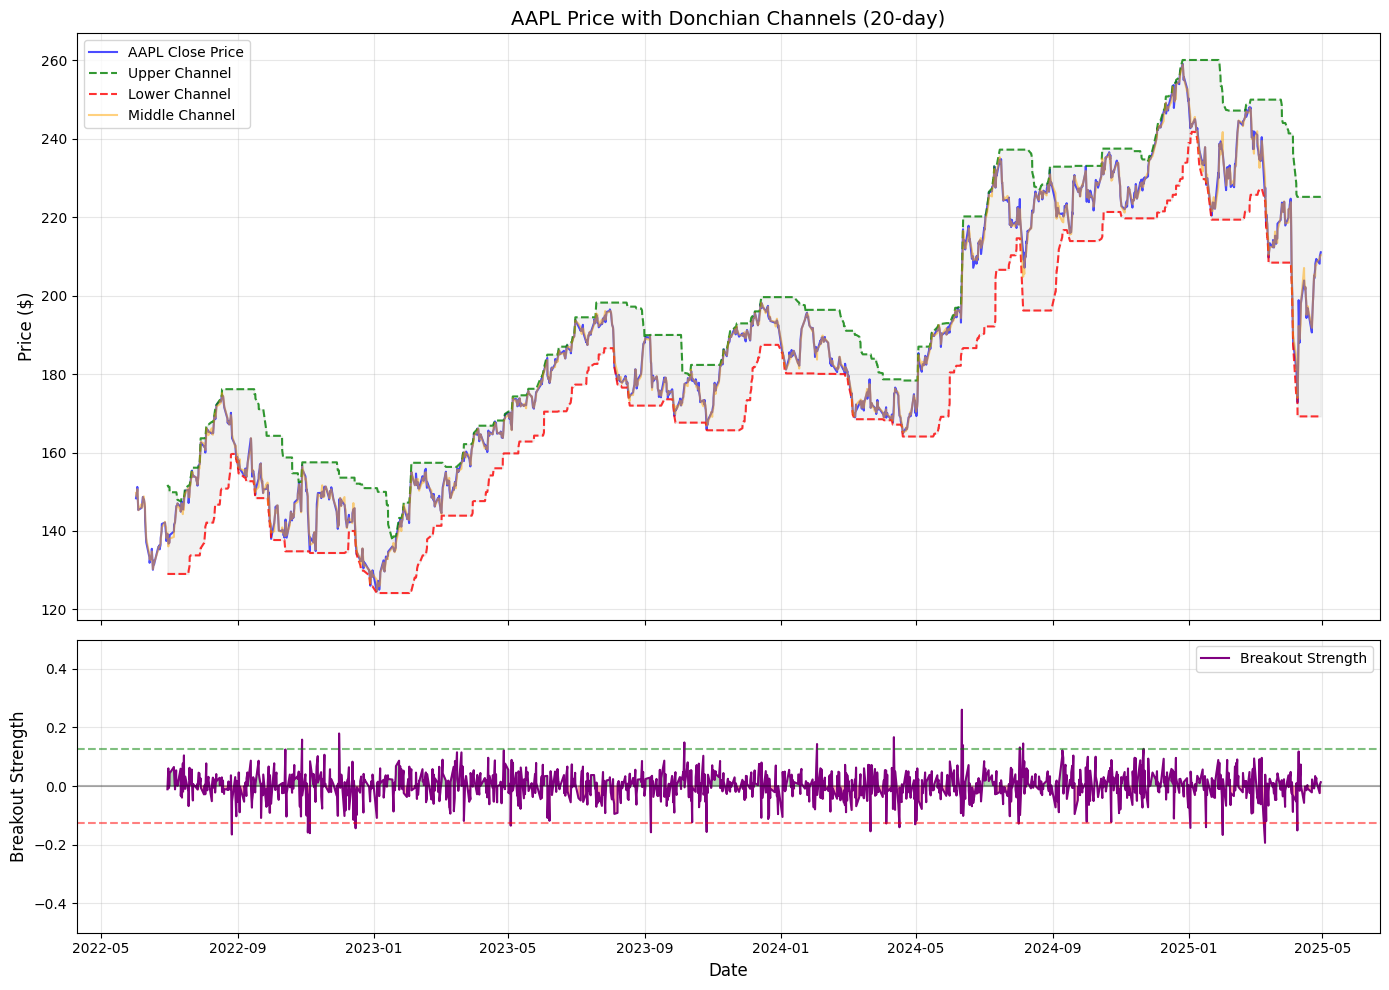

In [794]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Plot the price and Donchian Channels on the top subplot
ax1.plot(data.index, data['Close'], label='AAPL Close Price', color='blue', alpha=0.7)
ax1.plot(data.index, data['DC_Upper'], label='Upper Channel', color='green', linestyle='--', alpha=0.8)
ax1.plot(data.index, data['DC_Lower'], label='Lower Channel', color='red', linestyle='--', alpha=0.8)
ax1.plot(data.index, data['DC_Mid'], label='Middle Channel', color='orange', linestyle='-', alpha=0.5)
ax1.fill_between(data.index, data['DC_Upper'], data['DC_Lower'], color='gray', alpha=0.1)
ax1.set_title('AAPL Price with Donchian Channels (20-day)', fontsize=14)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# Plot the Breakout Strength on the bottom subplot
ax2.plot(data.index, data['DC_Breakout_Strength'], label='Breakout Strength', color='purple')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.axhline(y=0.125, color='green', linestyle='--', alpha=0.5)  # Strong bullish breakout threshold
ax2.axhline(y=-0.125, color='red', linestyle='--', alpha=0.5)   # Strong bearish breakout threshold
ax2.fill_between(data.index, data['DC_Breakout_Strength'], 0, 
                where=(data['DC_Breakout_Strength'] >= 0), 
                color='green', alpha=0.3)
ax2.fill_between(data.index, data['DC_Breakout_Strength'], 0, 
                where=(data['DC_Breakout_Strength'] <= 0), 
                color='red', alpha=0.3)
ax2.set_ylabel('Breakout Strength', fontsize=12)
ax2.set_ylim(-0.5, 0.5)  # Set reasonable limits for the indicator
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')

plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()

In [795]:
def add_volume_features(df: pd.DataFrame):
  volume_col = ("Volume", "AAPL")
  
  df["Vol_MA10"] = df[volume_col].rolling(window=10*2).mean()
  df["Vol_MA20"] = df[volume_col].rolling(window=20*2).mean()
  
  df["Vol_MA10_Ratio"] = df[volume_col] / df["Vol_MA10"]
  df["Vol_MA20_Ratio"] = df[volume_col] / df["Vol_MA20"]
  
  df["Vol_Spike"] = (df["Vol_MA10_Ratio"] > 1.5).astype(int)
  
  vol_mean = df[volume_col].rolling(window=20*2).mean()
  vol_std = df[volume_col].rolling(window=20*2).std()
  
  df["Vol_Z"] = (df[volume_col] - vol_mean) / vol_std
  
  return df

data = add_volume_features(data)

data.head()

Price,Close,High,Low,Open,Volume,MA5,MA10,MA20,RSI14,SD5,...,DC_Upper,DC_Mid,DC_Width,DC_Breakout_Strength,Vol_MA10,Vol_MA20,Vol_MA10_Ratio,Vol_MA20_Ratio,Vol_Spike,Vol_Z
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,...,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,,,
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,NaN,NaN,NaN,NaN,NaN,...,NaN,149.709999,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,NaN,NaN,NaN,NaN,NaN,...,NaN,149.000000,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,NaN,NaN,NaN,NaN,NaN,...,NaN,148.775002,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2022-06-02 17:30:00+00:00,151.229996,151.270004,150.029999,150.179993,19926032,NaN,NaN,NaN,NaN,NaN,...,NaN,150.650002,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2022-06-03 13:30:00+00:00,145.350006,147.970001,144.460007,147.000000,55128553,NaN,NaN,NaN,NaN,NaN,...,NaN,146.215004,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN


In [796]:
def add_mfi(df: pd.DataFrame, period=14):
  typical_price = (df["High"] + df["Low"] + df["Close"]) / 3

  raw_money_flow = typical_price * df["Volume"]

  delta_tp = typical_price.diff()

  pos_flow = raw_money_flow.where(delta_tp > 0, 0.0)
  neg_flow = raw_money_flow.where(delta_tp < 0, 0.0)

  pos_sum = pos_flow.rolling(window=period*2).sum()
  neg_sum = neg_flow.rolling(window=period*2).sum()

  money_flow_ratio = pos_sum / (neg_sum + 1e-9) # avoid div by zero

  money_flow_index = 100 - (100 / (1 + money_flow_ratio))

  df["MFI"] = money_flow_index

  return df

data = add_mfi(data)

data.iloc[100:200]

Price,Close,High,Low,Open,Volume,MA5,MA10,MA20,RSI14,SD5,...,DC_Mid,DC_Width,DC_Breakout_Strength,Vol_MA10,Vol_MA20,Vol_MA10_Ratio,Vol_MA20_Ratio,Vol_Spike,Vol_Z,MFI
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,...,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,,,
2022-08-12 13:30:00+00:00,171.479904,171.520004,169.399994,169.860001,38706430,167.195491,165.363326,159.445604,77.004420,2.424435,...,170.459999,24.820007,0.041092,28243635.15,2.977262e+07,1.370448,1.300068,0,0.814152,60.801224
2022-08-12 17:30:00+00:00,172.139999,172.169998,171.244995,171.479996,20423289,167.874490,165.841826,159.992854,78.877151,2.775546,...,171.707497,25.470001,0.016981,28114969.15,2.973020e+07,0.726420,0.686954,0,-0.845566,62.900250
2022-08-15 13:30:00+00:00,173.080002,173.300003,171.345001,171.520004,32647044,168.696490,166.418576,160.557861,81.482882,2.992328,...,172.322502,26.600006,0.028477,27870454.95,2.972627e+07,1.171385,1.098255,0,0.265389,66.497133
2022-08-15 17:30:00+00:00,173.190002,173.389999,172.830002,173.080002,14889721,169.527490,166.999576,161.209361,82.882663,2.968478,...,173.110001,26.479996,0.003021,27687100.15,2.913111e+07,0.537786,0.511128,0,-1.277157,68.488693
2022-08-16 13:30:00+00:00,172.949997,173.490005,171.661804,172.779999,31556503,170.294490,167.589576,161.786861,80.608180,2.730410,...,172.575905,23.641006,0.015824,27669019.50,2.880204e+07,1.140500,1.095634,0,0.253407,64.517977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-19 17:30:00+00:00,143.910004,143.960007,142.270004,142.679993,18600253,142.233501,141.570506,144.272353,51.557742,2.058538,...,143.115005,19.909897,0.039930,37009396.65,4.190357e+07,0.502582,0.443882,0,-1.430131,51.184876
2022-10-20 13:30:00+00:00,144.279999,145.889999,142.910004,143.020004,37707682,142.491501,141.460500,144.069197,53.906890,2.144141,...,144.400002,19.909897,-0.006027,36707566.60,4.157370e+07,1.027245,0.907008,0,-0.238038,55.649225


In [797]:
def add_z_close(df: pd.DataFrame):
  z_mean = df["Close"].rolling(window=20*2).mean()
  z_std = df["Close"].rolling(window=20*2).std()

  df["ZClose20"] = (df["Close"] - z_mean) / z_std

  return df

data = add_z_close(data)

data.iloc[100:200]

Price,Close,High,Low,Open,Volume,MA5,MA10,MA20,RSI14,SD5,...,DC_Width,DC_Breakout_Strength,Vol_MA10,Vol_MA20,Vol_MA10_Ratio,Vol_MA20_Ratio,Vol_Spike,Vol_Z,MFI,ZClose20
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,...,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,,,
2022-08-12 13:30:00+00:00,171.479904,171.520004,169.399994,169.860001,38706430,167.195491,165.363326,159.445604,77.004420,2.424435,...,24.820007,0.041092,28243635.15,2.977262e+07,1.370448,1.300068,0,0.814152,60.801224,1.781494
2022-08-12 17:30:00+00:00,172.139999,172.169998,171.244995,171.479996,20423289,167.874490,165.841826,159.992854,78.877151,2.775546,...,25.470001,0.016981,28114969.15,2.973020e+07,0.726420,0.686954,0,-0.845566,62.900250,1.766421
2022-08-15 13:30:00+00:00,173.080002,173.300003,171.345001,171.520004,32647044,168.696490,166.418576,160.557861,81.482882,2.992328,...,26.600006,0.028477,27870454.95,2.972627e+07,1.171385,1.098255,0,0.265389,66.497133,1.788281
2022-08-15 17:30:00+00:00,173.190002,173.389999,172.830002,173.080002,14889721,169.527490,166.999576,161.209361,82.882663,2.968478,...,26.479996,0.003021,27687100.15,2.913111e+07,0.537786,0.511128,0,-1.277157,68.488693,1.728075
2022-08-16 13:30:00+00:00,172.949997,173.490005,171.661804,172.779999,31556503,170.294490,167.589576,161.786861,80.608180,2.730410,...,23.641006,0.015824,27669019.50,2.880204e+07,1.140500,1.095634,0,0.253407,64.517977,1.612109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-19 17:30:00+00:00,143.910004,143.960007,142.270004,142.679993,18600253,142.233501,141.570506,144.272353,51.557742,2.058538,...,19.909897,0.039930,37009396.65,4.190357e+07,0.502582,0.443882,0,-1.430131,51.184876,-0.081167
2022-10-20 13:30:00+00:00,144.279999,145.889999,142.910004,143.020004,37707682,142.491501,141.460500,144.069197,53.906890,2.144141,...,19.909897,-0.006027,36707566.60,4.157370e+07,1.027245,0.907008,0,-0.238038,55.649225,0.049425


In [ ]:
def add_stochastic_oscillator(df: pd.DataFrame, k_period=14, d_period=3):
  high_max = df["High"].rolling(window=k_period*2).max()
  low_min = df["Low"].rolling(window=k_period*2).min()

  df["K%"] = 100 * ((df["Close"] - low_min) / (high_max - low_min + 1e-9)) # avoid div by zero
  df["D%"] = df["K%"].rolling(window=d_period*2).mean()

  return df

data = add_stochastic_oscillator(data)

data.head()

Price,Close,High,Low,Open,Volume,MA5,MA10,MA20,RSI14,SD5,...,Vol_MA10,Vol_MA20,Vol_MA10_Ratio,Vol_MA20_Ratio,Vol_Spike,Vol_Z,MFI,ZClose20,K%,D%
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,...,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,,,
2022-08-12 13:30:00+00:00,171.479904,171.520004,169.399994,169.860001,38706430,167.195491,165.363326,159.445604,77.004420,2.424435,...,28243635.15,2.977262e+07,1.370448,1.300068,0,0.814152,60.801224,1.781494,99.806467,93.111465
2022-08-12 17:30:00+00:00,172.139999,172.169998,171.244995,171.479996,20423289,167.874490,165.841826,159.992854,78.877151,2.775546,...,28114969.15,2.973020e+07,0.726420,0.686954,0,-0.845566,62.900250,1.766421,99.859622,95.919737
2022-08-15 13:30:00+00:00,173.080002,173.300003,171.345001,171.520004,32647044,168.696490,166.418576,160.557861,81.482882,2.992328,...,27870454.95,2.972627e+07,1.171385,1.098255,0,0.265389,66.497133,1.788281,99.006771,96.328420
2022-08-15 17:30:00+00:00,173.190002,173.389999,172.830002,173.080002,14889721,169.527490,166.999576,161.209361,82.882663,2.968478,...,27687100.15,2.913111e+07,0.537786,0.511128,0,-1.277157,68.488693,1.728075,99.055281,96.269853
2022-08-16 13:30:00+00:00,172.949997,173.490005,171.661804,172.779999,31556503,170.294490,167.589576,161.786861,80.608180,2.730410,...,27669019.50,2.880204e+07,1.140500,1.095634,0,0.253407,64.517977,1.612109,97.242040,97.114470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-19 17:30:00+00:00,143.910004,143.960007,142.270004,142.679993,18600253,142.233501,141.570506,144.272353,51.557742,2.058538,...,37009396.65,4.190357e+07,0.502582,0.443882,0,-1.430131,51.184876,-0.081167,71.484515,59.869014
2022-10-20 13:30:00+00:00,144.279999,145.889999,142.910004,143.020004,37707682,142.491501,141.460500,144.069197,53.906890,2.144141,...,36707566.60,4.157370e+07,1.027245,0.907008,0,-0.238038,55.649225,0.049425,74.391022,65.072747
